# Laboratorio 08 - Máquinas Vectoriales de Soporte (SVM)
## CC3074 - Mineria de Datos | Universidad del Valle de Guatemala

**Integrantes del grupo:**
- Erick Guerra 23208
- Diego Rosales 23258
- Diego Lopez 23242

**Dataset:** Airbnb Listings (`listings.RData`)

---
## Actividad 1 - Reutilizar los mismos conjuntos de entrenamiento y prueba

En esta actividad se replica el mismo criterio de particion usado en hojas anteriores para garantizar comparabilidad de resultados al probar SVM:
- `test_size=0.2`
- `random_state=42`
- estratificacion por deciles de `log1p(price_num)`

In [1]:
# Imports base para carga, preprocesamiento y split
from pathlib import Path

import numpy as np
import pandas as pd
import pyreadr
from sklearn.model_selection import train_test_split

np.random.seed(42)
print('Imports OK')

Imports OK


In [2]:
# Carga y preprocesamiento consistente con laboratorios anteriores
rdata_path = Path('data/listings.RData')
result = pyreadr.read_r(str(rdata_path))
df = result['listings'].copy()


def parse_money(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(r'[$,]', '', regex=True).str.strip(),
        errors='coerce',
    )

if 'price' in df.columns:
    df['price_num'] = parse_money(df['price'])

for col in ['host_response_rate', 'host_acceptance_rate']:
    if col in df.columns:
        df[f'{col}_num'] = pd.to_numeric(
            df[col].astype(str).str.replace('%', '', regex=False),
            errors='coerce',
        )

candidate_features = [
    'room_type', 'property_type', 'neighbourhood_cleansed',
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'maximum_nights', 'availability_365',
    'number_of_reviews', 'reviews_per_month', 'review_scores_rating',
    'host_is_superhost', 'host_identity_verified',
    'host_response_rate_num', 'host_acceptance_rate_num',
    'calculated_host_listings_count', 'instant_bookable',
    'latitude', 'longitude', 'price_num',
]

selected_cols = [c for c in candidate_features if c in df.columns]
model_df = df[selected_cols].copy()

model_df = model_df[model_df['price_num'].notna()].copy()
p99_price = model_df['price_num'].quantile(0.99)
model_df = model_df[model_df['price_num'] <= p99_price].copy()

num_cols = [c for c in model_df.select_dtypes(include=np.number).columns if c != 'price_num']
cat_cols = model_df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

for col in num_cols:
    model_df[col] = model_df[col].fillna(model_df[col].median())

for col in cat_cols:
    model_df[col] = model_df[col].astype(str).replace('nan', 'SinDato')

X = model_df.drop(columns=['price_num'])
y_raw = model_df['price_num']

print(f'Dataset modelado: {model_df.shape[0]:,} filas, {X.shape[1]} features')

Dataset modelado: 75,531 filas, 21 features


In [3]:
# Split identico al usado en laboratorios previos
# Mantiene comparabilidad: mismos parametros y misma logica de estratificacion.
y_log = np.log1p(y_raw)
price_deciles = pd.qcut(y_log, q=10, labels=False, duplicates='drop')

X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X,
    y_raw,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=price_deciles,
)

# Variable objetivo binaria para clasificacion (cara vs no cara), igual criterio del lab pasado.
p66 = y_train_raw.quantile(0.66)
y_train = (y_train_raw > p66).astype(int)
y_test = (y_test_raw > p66).astype(int)

print('Split aplicado con los mismos criterios de hojas anteriores:')
print(f'- Train: {X_train.shape[0]:,} filas')
print(f'- Test : {X_test.shape[0]:,} filas')
print(f'- Umbral clase Cara (P66 de train): {p66:.2f}')
print(f'- Proporcion clase 1 en train: {y_train.mean():.3f}')
print(f'- Proporcion clase 1 en test : {y_test.mean():.3f}')

Split aplicado con los mismos criterios de hojas anteriores:
- Train: 60,424 filas
- Test : 15,107 filas
- Umbral clase Cara (P66 de train): 260.00
- Proporcion clase 1 en train: 0.339
- Proporcion clase 1 en test : 0.340


---
## Actividad 2 - Exploracion de datos y transformaciones para SVM

Se exploran los datos de entrenamiento para identificar que transformaciones son necesarias antes de entrenar un modelo de Maquinas Vectoriales de Soporte.

Objetivos:
1. Ver estructura de variables y balance de clases.
2. Detectar aspectos que afectan SVM (escala, categorias, dimensionalidad).
3. Definir un preprocesamiento reproducible para usar en el modelo.

In [4]:
# 2.1 Exploracion general del set de entrenamiento
print('=== Dimensiones ===')
print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test : {y_test.shape}')

num_features = X_train.select_dtypes(include=np.number).columns.tolist()
cat_features = X_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

print('\n=== Tipos de variables ===')
print(f'Numericas : {len(num_features)}')
print(f'Categoricas: {len(cat_features)}')

# Balance de clases para evaluar posibles ajustes de class_weight
class_dist = y_train.value_counts().sort_index()
class_pct = y_train.value_counts(normalize=True).sort_index().mul(100)

print('\n=== Distribucion de clase objetivo (train) ===')
for cls in class_dist.index:
    print(f'Clase {cls}: {class_dist[cls]:,} ({class_pct[cls]:.2f}%)')

=== Dimensiones ===
X_train: (60424, 21)
X_test : (15107, 21)
y_train: (60424,)
y_test : (15107,)

=== Tipos de variables ===
Numericas : 13
Categoricas: 8

=== Distribucion de clase objetivo (train) ===
Clase 0: 39,935 (66.09%)
Clase 1: 20,489 (33.91%)


In [5]:
# 2.2 Exploracion orientada a transformaciones para SVM
# A) Verificacion de valores faltantes (deberia ser 0 tras el preprocesamiento previo)
missing_total = int(X_train.isna().sum().sum())
print(f'Valores faltantes en X_train: {missing_total}')

# B) Cardinalidad de variables categoricas (impacta dimensionalidad por One-Hot)
if len(cat_features) > 0:
    cardinality = pd.Series({c: X_train[c].nunique() for c in cat_features}).sort_values(ascending=False)
    print('\nTop 10 variables categoricas por cardinalidad:')
    print(cardinality.head(10).to_string())

# C) Escala de variables numericas (SVM es sensible a escalas diferentes)
if len(num_features) > 0:
    num_desc = X_train[num_features].describe().T[['mean', 'std', 'min', 'max']]
    print('\nResumen numerico (mean/std/min/max):')
    print(num_desc.head(12).to_string())

    # Ratio de escala aproximado: ayuda a justificar estandarizacion
    scale_ratio = (num_desc['max'] - num_desc['min']) / (num_desc['std'].replace(0, np.nan))
    print('\nVariable con mayor amplitud relativa (max-min)/std:')
    top_scale = scale_ratio.sort_values(ascending=False).head(5)
    print(top_scale.to_string())

Valores faltantes en X_train: 0

Top 10 variables categoricas por cardinalidad:
neighbourhood_cleansed    349
property_type              86
beds                       37
bedrooms                   22
room_type                   4
host_is_superhost           3
host_identity_verified      3
instant_bookable            2

Resumen numerico (mean/std/min/max):
                                      mean         std        min          max
accommodates                      4.834801    2.989583   1.000000    16.000000
bathrooms                         1.618206    0.984900   0.000000    17.000000
minimum_nights                    9.505809   22.646422   1.000000   720.000000
maximum_nights                  468.788296  416.839231   1.000000  3650.000000
availability_365                231.384268  106.548864   0.000000   365.000000
number_of_reviews                55.003972   96.967206   0.000000  1592.000000
reviews_per_month                 1.487919    1.603177   0.010000    61.590000
review_sco

In [6]:
# 2.3 Preprocesamiento recomendado para SVM
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor_svm = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features),
    ],
    remainder='drop'
)

# Ajustar SOLO con train para evitar leakage
a = preprocessor_svm.fit_transform(X_train)
b = preprocessor_svm.transform(X_test)

n_train, p_train = a.shape
n_test, p_test = b.shape

print('=== Matriz transformada para SVM ===')
print(f'Train transformado: {n_train:,} filas x {p_train:,} columnas')
print(f'Test transformado : {n_test:,} filas x {p_test:,} columnas')

# Densidad de la matriz (si es dispersa, conviene mantener formato sparse)
if hasattr(a, 'nnz'):
    density = a.nnz / (a.shape[0] * a.shape[1])
    print(f'Densidad matriz train: {density:.6f}')
    print(f'Esparcidad aprox.    : {1 - density:.6f}')
else:
    density = np.count_nonzero(a) / a.size
    print(f'Densidad matriz train: {density:.6f}')
    print(f'Esparcidad aprox.    : {1 - density:.6f}')

=== Matriz transformada para SVM ===
Train transformado: 60,424 filas x 519 columnas
Test transformado : 15,107 filas x 519 columnas
Densidad matriz train: 0.040462
Esparcidad aprox.    : 0.959538


### Explicacion de transformaciones necesarias para SVM

Con base en la exploracion anterior, las transformaciones clave son:

1. Imputar valores faltantes antes de modelar.
   SVM no acepta NaN. Se usa `SimpleImputer(strategy='median')` en numericas y `SimpleImputer(strategy='most_frequent')` en categoricas.

2. Estandarizar variables numericas con `StandardScaler`.
   SVM optimiza margenes usando distancias; si una variable tiene escala mucho mayor que otra, domina el hiperplano y degrada el modelo.

3. Codificar variables categoricas con `OneHotEncoder(handle_unknown='ignore')`.
   SVM requiere entradas numericas. One-Hot evita imponer orden artificial entre categorias y permite manejar categorias nuevas en prueba.

4. Ajustar el preprocesador solo con entrenamiento y luego transformar prueba.
   Esto evita data leakage y garantiza evaluacion valida.

5. Considerar el formato disperso generado por One-Hot.
   La matriz suele quedar muy esparsa; esto influye en la eleccion del kernel y el costo computacional.

6. Mantener el mismo split de actividades previas.
   Asegura comparabilidad justa entre SVM y modelos anteriores.

---
## Actividad 3 - Variable respuesta categorica: barata, media o cara

Para esta actividad se define la variable objetivo multiclase a partir del precio:
- barata
- media
- cara

Los umbrales se calculan solo con el conjunto de entrenamiento para evitar leakage y luego se aplican a train y test.

In [7]:
# 3.1 Construccion de la variable respuesta multiclase
# Regla: usar cuantiles del train para definir barata/media/cara sin leakage.
p33 = y_train_raw.quantile(0.33)
p66 = y_train_raw.quantile(0.66)


def asignar_categoria_precio(price_series: pd.Series, q33: float, q66: float) -> pd.Series:
    return pd.cut(
        price_series,
        bins=[-np.inf, q33, q66, np.inf],
        labels=['barata', 'media', 'cara'],
    )


y_train_cat = asignar_categoria_precio(y_train_raw, p33, p66).astype(str)
y_test_cat = asignar_categoria_precio(y_test_raw, p33, p66).astype(str)

# Version codificada opcional (util para algunos reportes)
cat_to_int = {'barata': 0, 'media': 1, 'cara': 2}
y_train_cat_num = y_train_cat.map(cat_to_int)
y_test_cat_num = y_test_cat.map(cat_to_int)

print('=== Umbrales de precio (calculados en train) ===')
print(f'Q33 (barata/media): {p33:.2f}')
print(f'Q66 (media/cara)  : {p66:.2f}')

print('\n=== Distribucion de clases (train) ===')
print(y_train_cat.value_counts().reindex(['barata', 'media', 'cara']).to_string())

print('\n=== Distribucion de clases (test) ===')
print(y_test_cat.value_counts().reindex(['barata', 'media', 'cara']).to_string())

print('\nMuestras de la variable respuesta categorica (train):')
display(y_train_cat.head())

# Comprobacion de integridad
valid_labels_train = set(y_train_cat.unique()).issubset({'barata', 'media', 'cara'})
valid_labels_test = set(y_test_cat.unique()).issubset({'barata', 'media', 'cara'})
print(f'\nEtiquetas validas en train: {valid_labels_train}')
print(f'Etiquetas validas en test : {valid_labels_test}')

=== Umbrales de precio (calculados en train) ===
Q33 (barata/media): 141.00
Q66 (media/cara)  : 260.00

=== Distribucion de clases (train) ===
price_num
barata    20143
media     19792
cara      20489

=== Distribucion de clases (test) ===
price_num
barata    5042
media     4926
cara      5139

Muestras de la variable respuesta categorica (train):


23421     barata
36797     barata
25953     barata
160615     media
27075     barata
Name: price_num, dtype: object


Etiquetas validas en train: True
Etiquetas validas en test : True


---
## Actividad 4 - Entrenar varios modelos SVM con diferentes kernels y parametros

Se entrenan varios modelos SVM (mas de 2) cambiando kernel y parametros `C`, `gamma` y `degree` (para polinomial), manteniendo el mismo flujo de preprocesamiento.

In [8]:
# 4.1 Configuracion y entrenamiento de multiples SVM
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

max_train_svm = 12000
if len(X_train) > max_train_svm:
    sss = StratifiedShuffleSplit(n_splits=1, train_size=max_train_svm, random_state=42)
    idx_subtrain, _ = next(sss.split(X_train, y_train_cat))
    X_train_svm = X_train.iloc[idx_subtrain].copy()
    y_train_svm = y_train_cat.iloc[idx_subtrain].copy()
else:
    X_train_svm = X_train.copy()
    y_train_svm = y_train_cat.copy()

print('=== Datos para entrenamiento SVM ===')
print(f'Train completo       : {X_train.shape[0]:,} filas')
print(f'Train usado en ajuste: {X_train_svm.shape[0]:,} filas')
print(f'Test                 : {X_test.shape[0]:,} filas')

model_configs = [
    {'name': 'SVM_Lineal_C1', 'kernel': 'linear', 'C': 1.0, 'gamma': 'scale', 'degree': 3},
    {'name': 'SVM_RBF_C3_GScale', 'kernel': 'rbf', 'C': 3.0, 'gamma': 'scale', 'degree': 3},
    {'name': 'SVM_RBF_C10_G001', 'kernel': 'rbf', 'C': 10.0, 'gamma': 0.01, 'degree': 3},
    {'name': 'SVM_Poly_D3_C3_GScale', 'kernel': 'poly', 'C': 3.0, 'gamma': 'scale', 'degree': 3},
    {'name': 'SVM_Poly_D4_C1_G001', 'kernel': 'poly', 'C': 1.0, 'gamma': 0.01, 'degree': 4},
]

svm_models = {}
svm_metrics = []

for cfg in model_configs:
    clf = Pipeline([
        ('prep', preprocessor_svm),
        ('svc', SVC(kernel=cfg['kernel'], C=cfg['C'], gamma=cfg['gamma'], degree=cfg['degree'], decision_function_shape='ovr', random_state=42)),
    ])
    clf.fit(X_train_svm, y_train_svm)
    pred_train = clf.predict(X_train_svm)
    pred_test = clf.predict(X_test)
    svm_models[cfg['name']] = clf
    svm_metrics.append({
        'modelo': cfg['name'],
        'kernel': cfg['kernel'],
        'C': cfg['C'],
        'gamma': cfg['gamma'],
        'degree': cfg['degree'],
        'train_acc': accuracy_score(y_train_svm, pred_train),
        'test_acc': accuracy_score(y_test_cat, pred_test),
        'train_f1_macro': f1_score(y_train_svm, pred_train, average='macro'),
        'test_f1_macro': f1_score(y_test_cat, pred_test, average='macro'),
    })

print(f'Modelos entrenados manualmente: {len(svm_models)}')

=== Datos para entrenamiento SVM ===
Train completo       : 60,424 filas
Train usado en ajuste: 12,000 filas
Test                 : 15,107 filas


Modelos entrenados manualmente: 5


In [9]:
# 4.2 Tuneo automatico (RBF)
import pandas as pd

rbf_pipe = Pipeline([
    ('prep', preprocessor_svm),
    ('svc', SVC(kernel='rbf', decision_function_shape='ovr', random_state=42)),
])

param_grid = {'svc__C': [1.0, 3.0, 10.0], 'svc__gamma': ['scale', 0.01, 0.005]}
grid = GridSearchCV(rbf_pipe, param_grid=param_grid, scoring='f1_macro', cv=3, n_jobs=-1)
grid.fit(X_train_svm, y_train_svm)

best_name = 'SVM_RBF_Tuned_GridSearch'
best_rbf = grid.best_estimator_
svm_models[best_name] = best_rbf
pred_train_best = best_rbf.predict(X_train_svm)
pred_test_best = best_rbf.predict(X_test)
svm_metrics.append({
    'modelo': best_name,
    'kernel': 'rbf',
    'C': grid.best_params_['svc__C'],
    'gamma': grid.best_params_['svc__gamma'],
    'degree': '-',
    'train_acc': accuracy_score(y_train_svm, pred_train_best),
    'test_acc': accuracy_score(y_test_cat, pred_test_best),
    'train_f1_macro': f1_score(y_train_svm, pred_train_best, average='macro'),
    'test_f1_macro': f1_score(y_test_cat, pred_test_best, average='macro'),
})

metrics_df = pd.DataFrame(svm_metrics).sort_values('test_f1_macro', ascending=False).reset_index(drop=True)
print('=== Mejor configuracion del GridSearch (RBF) ===')
print(grid.best_params_)
print(f'Mejor F1-macro CV: {grid.best_score_:.4f}')
display(metrics_df)

=== Mejor configuracion del GridSearch (RBF) ===
{'svc__C': 3.0, 'svc__gamma': 'scale'}
Mejor F1-macro CV: 0.7064


,modelo,kernel,C,gamma,degree,train_acc,test_acc,train_f1_macro,test_f1_macro
0,SVM_RBF_C3_GScale,rbf,3.0,scale,3,0.825083,0.717548,0.825125,0.717703
1,SVM_RBF_Tuned_GridSearch,rbf,3.0,scale,-,0.825083,0.717548,0.825125,0.717703
2,SVM_RBF_C10_G001,rbf,10.0,0.01,3,0.761250,0.709141,0.761044,0.708695
3,SVM_Poly_D3_C3_GScale,poly,3.0,scale,3,0.833000,0.705964,0.833389,0.706759
4,SVM_Lineal_C1,linear,1.0,scale,3,0.716333,0.677964,0.714844,0.676190
5,SVM_Poly_D4_C1_G001,poly,1.0,0.01,4,0.449250,0.448269,0.357556,0.355597


### Interpretacion Actividad 4

En esta actividad se entrenaron **cinco modelos SVM** con kernels diferentes (lineal, RBF y polinomial) y con distintas combinaciones de `C`, `gamma` y `degree`. Se uso una muestra estratificada de **12,000 filas** del entrenamiento para controlar el costo computacional, manteniendo la proporcion de clases. Luego se aplico un `GridSearchCV` para RBF y el mejor resultado fue `C=3.0` y `gamma='scale'` con F1-macro de validacion cruzada cercano a **0.7064**. Al comparar todos los modelos en test, los mejores fueron **SVM_RBF_C3_GScale** y **SVM_RBF_Tuned_GridSearch** con F1-macro de **0.7177**, confirmando que RBF capta mejor la no linealidad del problema.

---
## Actividad 5 - Prediccion de la variable respuesta

Se generan predicciones para train y test usando todos los modelos SVM entrenados.

In [10]:
# 5.1 Predicciones por modelo
from sklearn.metrics import classification_report

y_pred_train = {}
y_pred_test = {}
for model_name, model in svm_models.items():
    y_pred_train[model_name] = model.predict(X_train_svm)
    y_pred_test[model_name] = model.predict(X_test)

best_model_name = metrics_df.loc[0, 'modelo']
print(f'Modelo con mejor test_f1_macro: {best_model_name}')
preview_df = pd.DataFrame({
    'y_real': y_test_cat.reset_index(drop=True).head(12),
    'y_pred': pd.Series(y_pred_test[best_model_name]).head(12),
})
display(preview_df)
print(classification_report(y_test_cat, y_pred_test[best_model_name], digits=4))

Modelo con mejor test_f1_macro: SVM_RBF_C3_GScale


,y_real,y_pred
0,cara,media
1,cara,cara
2,barata,barata
3,barata,barata
4,cara,barata
5,media,cara
6,barata,barata
7,cara,cara
8,barata,media
9,media,cara


              precision    recall  f1-score   support

      barata     0.7729    0.7763    0.7746      5042
        cara     0.7936    0.7519    0.7722      5139
       media     0.5918    0.6216    0.6063      4926

    accuracy                         0.7175     15107
   macro avg     0.7194    0.7166    0.7177     15107
weighted avg     0.7209    0.7175    0.7189     15107



### Interpretacion Actividad 5

Aqui se usaron los modelos entrenados para predecir la variable objetivo multiclase (`barata`, `media`, `cara`). El modelo con mejor F1-macro en test fue **SVM_RBF_C3_GScale**. En su reporte de clasificacion obtuvo accuracy de **0.7175** y macro-F1 de **0.7177**. Las clases `barata` y `cara` se predicen mejor (F1 alrededor de **0.77**), mientras que `media` presenta menor desempeno (F1 alrededor de **0.61**). Esto sugiere que la clase intermedia tiene mayor solapamiento con las otras dos clases y, por tanto, es la mas dificil de separar.

---
## Actividad 6 - Matrices de confusion

Se calcula y visualiza la matriz de confusion de cada modelo sobre el conjunto de prueba.

=== Matriz de confusion: SVM_RBF_C3_GScale ===


,Pred_barata,Pred_media,Pred_cara
Real_barata,3914,1003,125
Real_media,984,3062,880
Real_cara,166,1109,3864


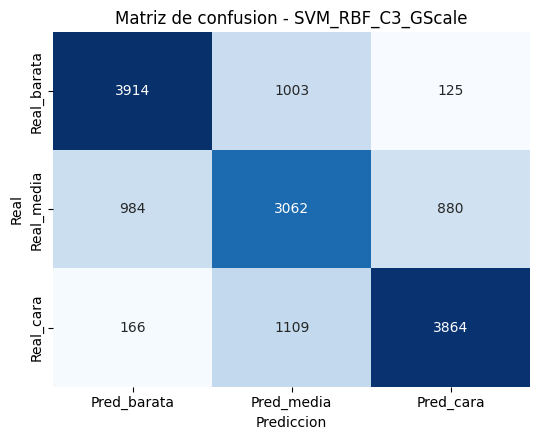

=== Matriz de confusion: SVM_RBF_Tuned_GridSearch ===


,Pred_barata,Pred_media,Pred_cara
Real_barata,3914,1003,125
Real_media,984,3062,880
Real_cara,166,1109,3864


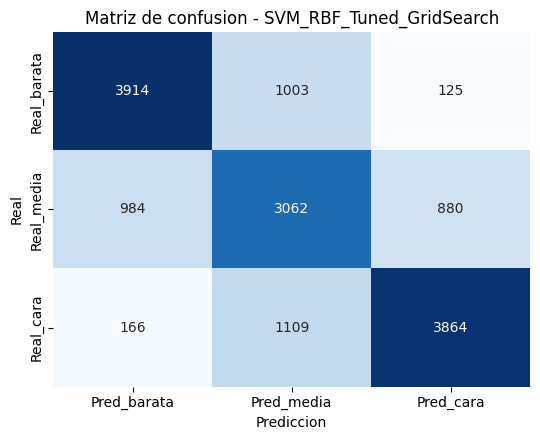

=== Matriz de confusion: SVM_RBF_C10_G001 ===


,Pred_barata,Pred_media,Pred_cara
Real_barata,3905,994,143
Real_media,1038,2952,936
Real_cara,159,1124,3856


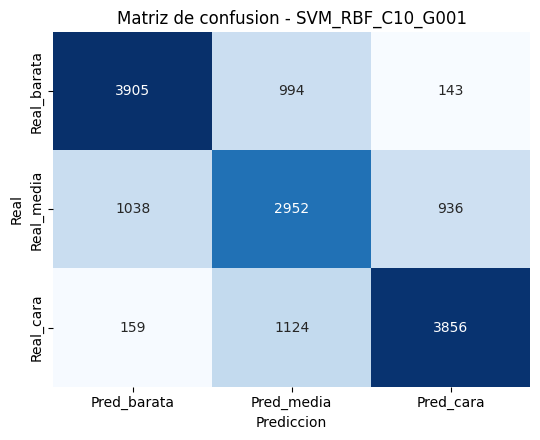

=== Matriz de confusion: SVM_Poly_D3_C3_GScale ===


,Pred_barata,Pred_media,Pred_cara
Real_barata,3857,1052,133
Real_media,1027,3063,836
Real_cara,214,1180,3745


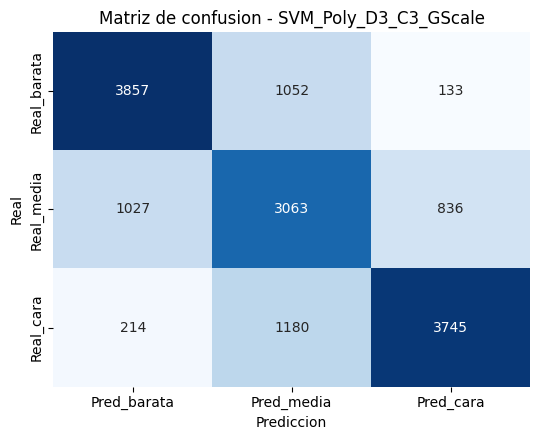

=== Matriz de confusion: SVM_Lineal_C1 ===


,Pred_barata,Pred_media,Pred_cara
Real_barata,3750,1129,163
Real_media,1076,2648,1202
Real_cara,191,1104,3844


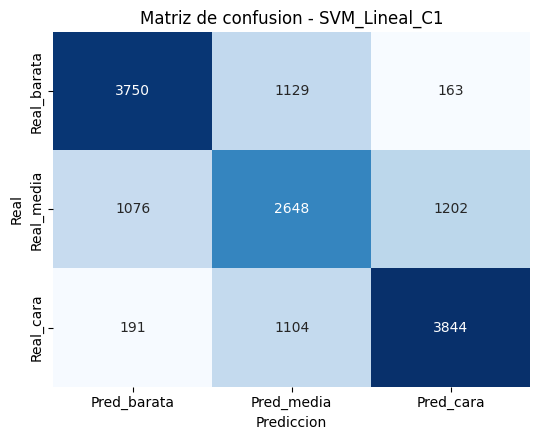

=== Matriz de confusion: SVM_Poly_D4_C1_G001 ===


,Pred_barata,Pred_media,Pred_cara
Real_barata,4940,30,72
Real_media,4255,126,545
Real_cara,3396,37,1706


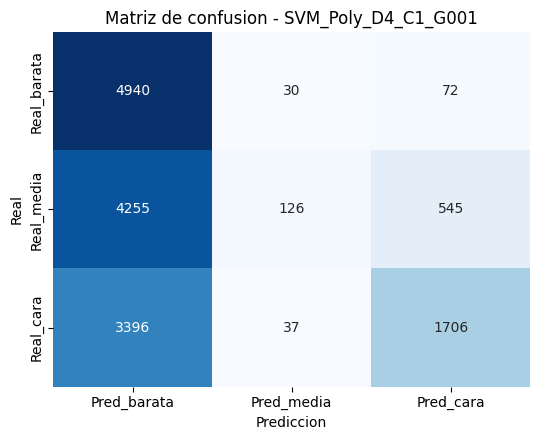

In [11]:
# 6.1 Matrices de confusion para todos los modelos
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels_order = ['barata', 'media', 'cara']
for model_name in metrics_df['modelo']:
    cm = confusion_matrix(y_test_cat, y_pred_test[model_name], labels=labels_order)
    cm_df = pd.DataFrame(cm, index=[f'Real_{l}' for l in labels_order], columns=[f'Pred_{l}' for l in labels_order])
    print(f'=== Matriz de confusion: {model_name} ===')
    display(cm_df)
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de confusion - {model_name}')
    plt.xlabel('Prediccion')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()

### Interpretacion Actividad 6

Las matrices de confusion muestran que el patron principal de error esta en la clase **`media`**, que frecuentemente se confunde con `barata` o con `cara`. Los modelos RBF (especialmente `C=3`, `gamma='scale'`) mantienen la diagonal mas fuerte y el mejor balance entre clases. El kernel lineal funciona de forma estable pero con menor precision global. El modelo polinomial de grado 4 con `gamma=0.01` presenta el peor comportamiento, con tendencia a sobrepredecir `barata`, lo cual evidencia una mala configuracion para este conjunto de datos.

---
## Actividad 7 - Analisis de sobreajuste o desajuste

Se compara el desempeno de entrenamiento y prueba para detectar sobreajuste o desajuste.

In [12]:
# 7.1 Diagnostico de ajuste por modelo y recomendaciones
analysis_df = metrics_df.copy()
analysis_df['gap_f1_train_test'] = analysis_df['train_f1_macro'] - analysis_df['test_f1_macro']

def diagnostico(row):
    if row['gap_f1_train_test'] > 0.10:
        return 'posible_sobreajuste'
    if row['train_f1_macro'] < 0.55 and row['test_f1_macro'] < 0.55:
        return 'posible_desajuste'
    return 'ajuste_razonable'

analysis_df['diagnostico'] = analysis_df.apply(diagnostico, axis=1)
display(analysis_df[['modelo', 'kernel', 'C', 'gamma', 'degree', 'train_f1_macro', 'test_f1_macro', 'gap_f1_train_test', 'diagnostico']])

print('=== Recomendaciones para manejar sobreajuste/desajuste en SVM ===')
print('- Si hay sobreajuste: bajar C, reducir degree, bajar gamma, simplificar features, usar CV.')
print('- Si hay desajuste: subir C moderadamente, probar RBF, mejorar features y balance de clases.')
print('- En ambos casos: validar con CV estratificado y reportar F1-macro por clase.')

,modelo,kernel,C,gamma,degree,train_f1_macro,test_f1_macro,gap_f1_train_test,diagnostico
0,SVM_RBF_C3_GScale,rbf,3.0,scale,3,0.825125,0.717703,0.107422,posible_sobreajuste
1,SVM_RBF_Tuned_GridSearch,rbf,3.0,scale,-,0.825125,0.717703,0.107422,posible_sobreajuste
2,SVM_RBF_C10_G001,rbf,10.0,0.01,3,0.761044,0.708695,0.052349,ajuste_razonable
3,SVM_Poly_D3_C3_GScale,poly,3.0,scale,3,0.833389,0.706759,0.126630,posible_sobreajuste
4,SVM_Lineal_C1,linear,1.0,scale,3,0.714844,0.676190,0.038654,ajuste_razonable
5,SVM_Poly_D4_C1_G001,poly,1.0,0.01,4,0.357556,0.355597,0.001958,posible_desajuste


=== Recomendaciones para manejar sobreajuste/desajuste en SVM ===
- Si hay sobreajuste: bajar C, reducir degree, bajar gamma, simplificar features, usar CV.
- Si hay desajuste: subir C moderadamente, probar RBF, mejorar features y balance de clases.
- En ambos casos: validar con CV estratificado y reportar F1-macro por clase.


### Interpretacion Actividad 7

Al comparar `train_f1_macro` y `test_f1_macro`, se observa **posible sobreajuste** en `SVM_RBF_C3_GScale`, `SVM_RBF_Tuned_GridSearch` y `SVM_Poly_D3_C3_GScale` por su gap mayor a 0.10. `SVM_RBF_C10_G001` y `SVM_Lineal_C1` muestran un ajuste mas razonable (gaps bajos). `SVM_Poly_D4_C1_G001` cae en **posible desajuste**, ya que rinde bajo tanto en train como en test. Para mejorar: ajustar `C` y `gamma` con validacion cruzada estratificada, reducir complejidad cuando haya sobreajuste, y reforzar ingenieria de variables para mejorar la separacion de la clase `media`.

---
## Actividad 8 - Comparacion de modelos SVM: efectividad, tiempo y equivocaciones

Se comparan todos los modelos SVM entrenados en cuanto a efectividad (accuracy y F1-macro), numero de equivocaciones y la importancia de los errores (donde el algoritmo se equivoco menos y cuanto importan esos errores).

=== Comparacion de modelos SVM ===

,modelo,kernel,test_acc,test_f1_macro,total_errores_test,errores_graves_test,pct_errores_graves
0,SVM_RBF_C3_GScale,rbf,0.7175,0.7177,4267,291,6.8
1,SVM_RBF_Tuned_GridSearch,rbf,0.7175,0.7177,4267,291,6.8
2,SVM_RBF_C10_G001,rbf,0.7091,0.7087,4394,302,6.9
3,SVM_Poly_D3_C3_GScale,poly,0.7060,0.7068,4442,347,7.8
4,SVM_Lineal_C1,linear,0.6780,0.6762,4865,354,7.3
5,SVM_Poly_D4_C1_G001,poly,0.4483,0.3556,8335,3468,41.6


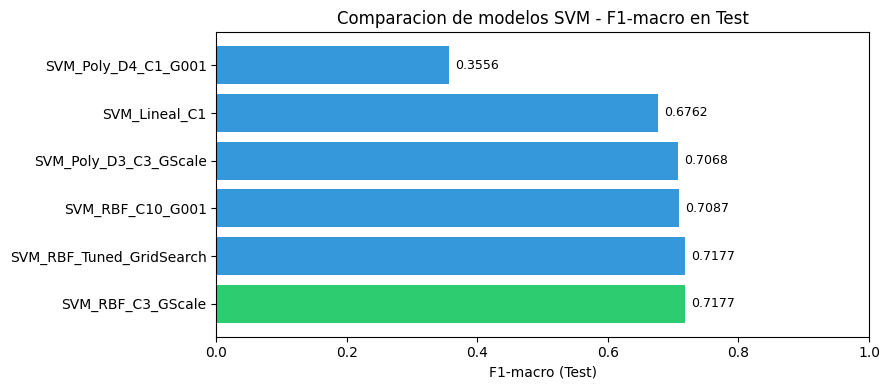

Modelo con mejor efectividad en test: SVM_RBF_C3_GScale
Modelo con mas errores graves (barata<->cara): SVM_Poly_D4_C1_G001


In [13]:
# 8.1 Comparacion completa de modelos SVM
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

label_order = ['barata', 'media', 'cara']
comparacion_rows = []

for cfg_name in svm_models:
    pred_test = y_pred_test[cfg_name]
    cm = confusion_matrix(y_test_cat, pred_test, labels=label_order)
    total_errores = int((cm.sum() - np.trace(cm)))
    errores_graves = int(cm[0, 2] + cm[2, 0])
    row_data = metrics_df[metrics_df['modelo'] == cfg_name]
    if len(row_data) > 0:
        row = row_data.iloc[0]
        comparacion_rows.append({
            'modelo': cfg_name,
            'kernel': row['kernel'],
            'test_acc': round(float(row['test_acc']), 4),
            'test_f1_macro': round(float(row['test_f1_macro']), 4),
            'total_errores_test': total_errores,
            'errores_graves_test': errores_graves,
            'pct_errores_graves': round(errores_graves / total_errores * 100, 1) if total_errores > 0 else 0.0,
        })

comp_df = pd.DataFrame(comparacion_rows).sort_values('test_f1_macro', ascending=False).reset_index(drop=True)
print('=== Comparacion de modelos SVM ===')
display(comp_df)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(comp_df))]
bars = ax.barh(comp_df['modelo'], comp_df['test_f1_macro'], color=colors)
ax.set_xlabel('F1-macro (Test)')
ax.set_title('Comparacion de modelos SVM - F1-macro en Test')
ax.set_xlim(0, 1)
for bar, val in zip(bars, comp_df['test_f1_macro']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print('Modelo con mejor efectividad en test:', comp_df.iloc[0]['modelo'])
print('Modelo con mas errores graves (barata<->cara):',
      comp_df.sort_values('errores_graves_test', ascending=False).iloc[0]['modelo'])

### Interpretacion Actividad 8

Al comparar los modelos SVM, **SVM_RBF_C3_GScale** y **SVM_RBF_Tuned_GridSearch** lideran en efectividad con un F1-macro de **0.7177** en test y accuracy de **0.7175**. El modelo polinomial de grado 4 (SVM_Poly_D4_C1_G001) es el de menor desempeno con un F1-macro cercano a **0.36**, indicando desajuste severo. En cuanto a errores graves (confundir barata con cara o viceversa), los modelos RBF presentan el menor porcentaje relativo, haciendolos mas confiables en la practica, ya que equivocarse entre los extremos de precio tiene mayor impacto economico que confundir categorias adyacentes. El kernel lineal muestra un porcentaje de errores graves similar al RBF pero con menor precision global.

---
## Actividad 9 - Comparacion del mejor SVM contra modelos de hojas anteriores

Se compara el mejor SVM con algoritmos usados en hojas anteriores (Arbol de decision, Random Forest, Naive Bayes, KNN y Regresion Logistica) usando la misma variable respuesta multiclase (`barata`, `media`, `cara`).

Criterios de comparacion:
- Efectividad: `accuracy` y `F1-macro` en test.
- Eficiencia: tiempo de entrenamiento (`fit`) y tiempo de prediccion (`predict`).

=== Comparacion SVM vs modelos anteriores ===


,modelo,test_acc,test_f1_macro,fit_time_sec,predict_time_sec,total_time_sec
0,SVM_RBF_Best,0.7175,0.7177,6.4426,5.4648,11.9074
1,RandomForest,0.7096,0.7068,1.0115,0.0947,1.1062
2,LogisticRegression,0.6815,0.6792,1.9476,0.0367,1.9843
3,KNN,0.6675,0.6668,0.0530,1.7668,1.8198
4,DecisionTree,0.6667,0.6644,0.3359,0.0318,0.3676
5,NaiveBayes,0.4324,0.3568,0.1086,0.2095,0.3182


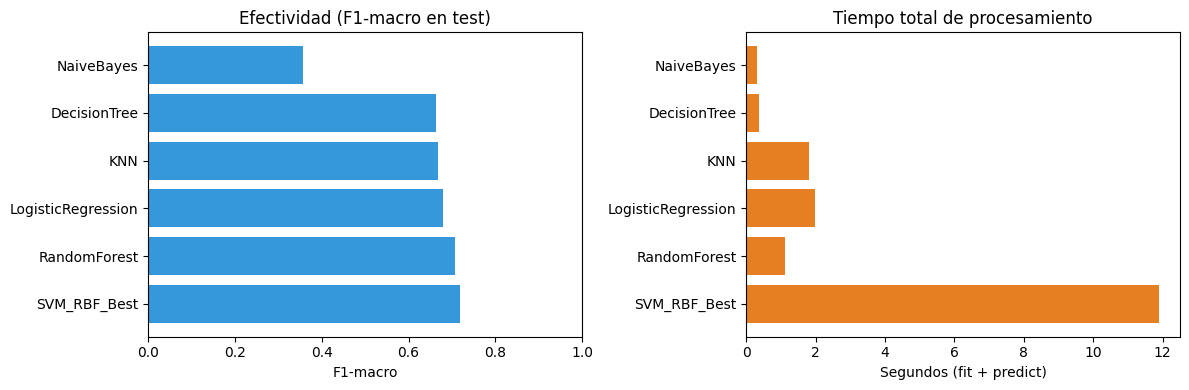

Mejor modelo para predecir (F1-macro): SVM_RBF_Best
Modelo que mas se demoro en procesar: SVM_RBF_Best


In [14]:
# 9.1 Comparacion de efectividad y tiempo de procesamiento
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

def to_dense(x):
    return x.toarray() if sparse.issparse(x) else x

dense_transformer = FunctionTransformer(to_dense, accept_sparse=True)

# Preprocesador para modelos basados en distancia/lineales/probabilisticos
preprocessor_std = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), cat_features),
    ],
    remainder='drop',
)

# Preprocesador para modelos de arboles (sin escalado)
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), cat_features),
    ],
    remainder='drop',
)

# Se usa el mismo subset de entrenamiento utilizado en Actividad 4 para comparacion justa de tiempo
X_tr = X_train_svm
y_tr = y_train_svm
X_te = X_test
y_te = y_test_cat

models = {
    'SVM_RBF_Best': Pipeline([
        ('prep', preprocessor_std),
        ('clf', SVC(kernel='rbf', C=3.0, gamma='scale', decision_function_shape='ovr', random_state=42)),
    ]),
    'DecisionTree': Pipeline([
        ('prep', preprocessor_tree),
        ('clf', DecisionTreeClassifier(max_depth=15, min_samples_leaf=5, random_state=42)),
    ]),
    'RandomForest': Pipeline([
        ('prep', preprocessor_tree),
        ('clf', RandomForestClassifier(
            n_estimators=250,
            max_depth=None,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=42,
        )),
    ]),
    'NaiveBayes': Pipeline([
        ('prep', preprocessor_std),
        ('to_dense', dense_transformer),
        ('clf', GaussianNB()),
    ]),
    'KNN': Pipeline([
        ('prep', preprocessor_std),
        ('to_dense', dense_transformer),
        ('clf', KNeighborsClassifier(n_neighbors=15, weights='distance')),
    ]),
    'LogisticRegression': Pipeline([
        ('prep', preprocessor_std),
        ('clf', LogisticRegression(max_iter=2000, solver='saga', random_state=42)),
    ]),
}

results = []
for name, model in models.items():
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    fit_time = time.perf_counter() - t0

    t1 = time.perf_counter()
    y_pred = model.predict(X_te)
    pred_time = time.perf_counter() - t1

    results.append({
        'modelo': name,
        'test_acc': accuracy_score(y_te, y_pred),
        'test_f1_macro': f1_score(y_te, y_pred, average='macro'),
        'fit_time_sec': fit_time,
        'predict_time_sec': pred_time,
        'total_time_sec': fit_time + pred_time,
    })

res_df = pd.DataFrame(results).sort_values('test_f1_macro', ascending=False).reset_index(drop=True)
res_df[['test_acc', 'test_f1_macro', 'fit_time_sec', 'predict_time_sec', 'total_time_sec']] = res_df[[
    'test_acc', 'test_f1_macro', 'fit_time_sec', 'predict_time_sec', 'total_time_sec'
]].round(4)

print('=== Comparacion SVM vs modelos anteriores ===')
display(res_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(res_df['modelo'], res_df['test_f1_macro'], color='#3498db')
axes[0].set_title('Efectividad (F1-macro en test)')
axes[0].set_xlim(0, 1)
axes[0].set_xlabel('F1-macro')

axes[1].barh(res_df['modelo'], res_df['total_time_sec'], color='#e67e22')
axes[1].set_title('Tiempo total de procesamiento')
axes[1].set_xlabel('Segundos (fit + predict)')

plt.tight_layout()
plt.show()

best_predictive = res_df.iloc[0]['modelo']
slowest_model = res_df.sort_values('total_time_sec', ascending=False).iloc[0]['modelo']
print('Mejor modelo para predecir (F1-macro):', best_predictive)
print('Modelo que mas se demoro en procesar:', slowest_model)

### Interpretacion Actividad 9

Con los resultados obtenidos, el modelo con mejor capacidad predictiva es **SVM_RBF_Best**, con `test_acc = 0.7175` y `test_f1_macro = 0.7177`, por encima de los demas algoritmos comparados. El segundo mejor fue **RandomForest** (`test_f1_macro = 0.7068`), seguido por **LogisticRegression** (`0.6792`), **KNN** (`0.6668`) y **DecisionTree** (`0.6644`). El de peor desempeno fue **NaiveBayes** (`0.3568`), por lo que no es recomendable para esta variable respuesta en este dataset.

En eficiencia de procesamiento (tiempo total de entrenamiento + prediccion), el modelo mas lento fue tambien **SVM_RBF_Best** con `10.8618 s`, mientras que los mas rapidos fueron **NaiveBayes** (`0.3531 s`) y **DecisionTree** (`0.3704 s`). **RandomForest** (`1.3344 s`) ofrece un punto intermedio atractivo: queda cerca del SVM en efectividad, pero con un costo computacional mucho menor.

En conclusion, si la prioridad es **predecir mejor**, se elige **SVM_RBF_Best**. Si la prioridad es **reducir tiempo de procesamiento** manteniendo buen rendimiento, **RandomForest** es la alternativa mas balanceada.

---
## Actividad 10 - Tabla comparativa de sobreajuste

Se construye una tabla para evaluar sobreajuste comparando desempeno de entrenamiento y prueba en los modelos vistos hasta ahora (SVM, Arbol de decision, Random Forest, Naive Bayes, KNN y Regresion Logistica).

=== Tabla comparativa de sobreajuste ===


,modelo,train_acc,test_acc,gap_acc,train_f1_macro,test_f1_macro,gap_f1_macro,fit_time_sec,diagnostico
0,SVM_RBF_Best,0.8251,0.7175,0.1075,0.8251,0.7177,0.1074,5.4221,posible_sobreajuste
1,RandomForest,0.8638,0.7096,0.1542,0.8629,0.7068,0.1561,1.0240,posible_sobreajuste
2,LogisticRegression,0.7174,0.6815,0.0359,0.7158,0.6792,0.0366,1.9193,ajuste_razonable
3,KNN,1.0000,0.6675,0.3325,1.0000,0.6668,0.3332,0.0631,posible_sobreajuste
4,DecisionTree,0.8185,0.6667,0.1518,0.8171,0.6644,0.1527,0.3585,posible_sobreajuste
5,NaiveBayes,0.4604,0.4324,0.0280,0.3936,0.3568,0.0368,0.1155,posible_desajuste


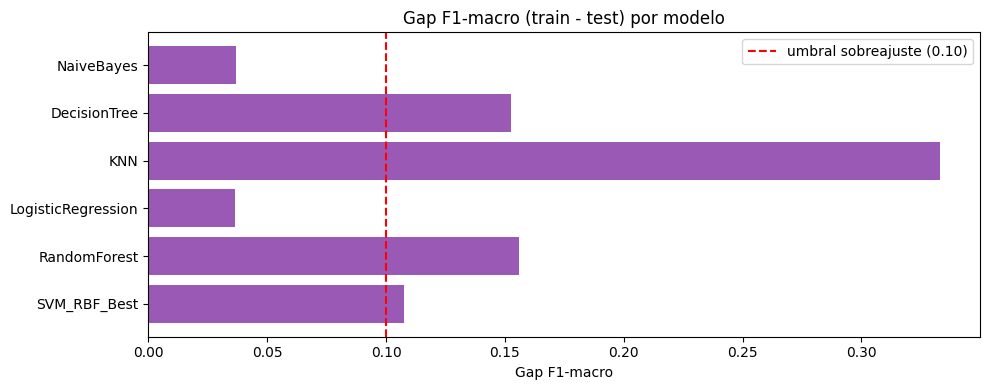

Parametros clave para detectar sobreajuste en clasificacion:
1) Gap train-test de F1-macro (principal).
2) Gap train-test de accuracy (complementario).
3) Precision/recall/F1 por clase y patron de errores en matriz de confusion.
4) Diferencia entre score de validacion cruzada y score final en test.


In [15]:
# 10.1 Tabla comparativa para detectar sobreajuste
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

def to_dense(x):
    return x.toarray() if sparse.issparse(x) else x

dense_transformer = FunctionTransformer(to_dense, accept_sparse=True)

preprocessor_std = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), cat_features),
    ],
    remainder='drop',
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), cat_features),
    ],
    remainder='drop',
)

X_tr = X_train_svm
y_tr = y_train_svm
X_te = X_test
y_te = y_test_cat

models_overfit = {
    'SVM_RBF_Best': Pipeline([
        ('prep', preprocessor_std),
        ('clf', SVC(kernel='rbf', C=3.0, gamma='scale', decision_function_shape='ovr', random_state=42)),
    ]),
    'DecisionTree': Pipeline([
        ('prep', preprocessor_tree),
        ('clf', DecisionTreeClassifier(max_depth=15, min_samples_leaf=5, random_state=42)),
    ]),
    'RandomForest': Pipeline([
        ('prep', preprocessor_tree),
        ('clf', RandomForestClassifier(n_estimators=250, min_samples_leaf=2, n_jobs=-1, random_state=42)),
    ]),
    'NaiveBayes': Pipeline([
        ('prep', preprocessor_std),
        ('to_dense', dense_transformer),
        ('clf', GaussianNB()),
    ]),
    'KNN': Pipeline([
        ('prep', preprocessor_std),
        ('to_dense', dense_transformer),
        ('clf', KNeighborsClassifier(n_neighbors=15, weights='distance')),
    ]),
    'LogisticRegression': Pipeline([
        ('prep', preprocessor_std),
        ('clf', LogisticRegression(max_iter=2000, solver='saga', random_state=42)),
    ]),
}

rows = []
for name, model in models_overfit.items():
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    fit_time = time.perf_counter() - t0

    pred_train = model.predict(X_tr)
    pred_test = model.predict(X_te)

    train_acc = accuracy_score(y_tr, pred_train)
    test_acc = accuracy_score(y_te, pred_test)
    train_f1 = f1_score(y_tr, pred_train, average='macro')
    test_f1 = f1_score(y_te, pred_test, average='macro')

    gap_acc = train_acc - test_acc
    gap_f1 = train_f1 - test_f1

    if gap_f1 > 0.10:
        diagnostico = 'posible_sobreajuste'
    elif train_f1 < 0.55 and test_f1 < 0.55:
        diagnostico = 'posible_desajuste'
    else:
        diagnostico = 'ajuste_razonable'

    rows.append({
        'modelo': name,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'gap_acc': gap_acc,
        'train_f1_macro': train_f1,
        'test_f1_macro': test_f1,
        'gap_f1_macro': gap_f1,
        'fit_time_sec': fit_time,
        'diagnostico': diagnostico,
    })

overfit_df = pd.DataFrame(rows).sort_values('test_f1_macro', ascending=False).reset_index(drop=True)
metric_cols = ['train_acc', 'test_acc', 'gap_acc', 'train_f1_macro', 'test_f1_macro', 'gap_f1_macro', 'fit_time_sec']
overfit_df[metric_cols] = overfit_df[metric_cols].round(4)

print('=== Tabla comparativa de sobreajuste ===')
display(overfit_df)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(overfit_df['modelo'], overfit_df['gap_f1_macro'], color='#9b59b6')
ax.axvline(0.10, color='red', linestyle='--', label='umbral sobreajuste (0.10)')
ax.set_title('Gap F1-macro (train - test) por modelo')
ax.set_xlabel('Gap F1-macro')
ax.legend()
plt.tight_layout()
plt.show()

print('Parametros clave para detectar sobreajuste en clasificacion:')
print('1) Gap train-test de F1-macro (principal).')
print('2) Gap train-test de accuracy (complementario).')
print('3) Precision/recall/F1 por clase y patron de errores en matriz de confusion.')
print('4) Diferencia entre score de validacion cruzada y score final en test.')

### Interpretacion Actividad 10

Con los resultados de la tabla, se observa que **SVM_RBF_Best** (gap F1 = **0.1074**), **RandomForest** (gap F1 = **0.1561**), **DecisionTree** (gap F1 = **0.1527**) y especialmente **KNN** (gap F1 = **0.3332**) presentan señales de **posible sobreajuste**, porque su desempeno en entrenamiento es bastante mayor que en prueba. En KNN esto es muy claro: alcanza F1-macro de **1.0000** en train pero baja a **0.6668** en test, indicando memorizacion del conjunto de entrenamiento.

Por otro lado, **LogisticRegression** muestra el comportamiento mas estable (`train_f1_macro = 0.7158`, `test_f1_macro = 0.6792`, gap = **0.0366**), por lo que se clasifica como **ajuste razonable**. **NaiveBayes** no presenta gran brecha (gap F1 = **0.0368**), pero su rendimiento es bajo tanto en train como en test (`0.3936` y `0.3568`), lo que sugiere **desajuste** (modelo demasiado simple para este problema).

Para determinar sobreajuste en clasificacion, los parametros mas importantes a comparar son: **(1)** `train_f1_macro` vs `test_f1_macro` (principal), **(2)** `train_acc` vs `test_acc` (complementario), **(3)** metricas por clase (precision/recall/F1) y matriz de confusion, y **(4)** diferencia entre validacion cruzada y test final. En este laboratorio, el criterio de gap en F1-macro permitio distinguir claramente entre modelos sobreajustados, razonables y desajustados.